# Análisis Exploratorio de Datos (EDA) Avanzado - Dataset DREAMER

Este notebook realiza un análisis exploratorio de datos (EDA) detallado y robusto del dataset DREAMER, un recurso para la investigación en computación afectiva que contiene señales de Electrocardiograma (ECG) y Electroencefalograma (EEG) de 23 participantes mientras veían 18 videoclips diseñados para provocar diferentes emociones.

## 1. Objetivos del Análisis

El objetivo de este EDA es ir más allá de la descripción básica y profundizar en la relación entre las señales fisiológicas y los estados emocionales:

1.  **Comprender y Estructurar el Dataset**: Cargar y transformar los datos desde su formato original (`.mat`) a una estructura tabular manejable.
2.  **Análisis Descriptivo**: Explorar la distribución de las variables demográficas y emocionales, incluyendo estadísticas básicas, normalidad y variabilidad entre sujetos.
3.  **Extracción de Características Fisiológicas**: Calcular métricas clave del dominio del tiempo y la frecuencia para las señales de ECG (HRV) y EEG (Potencia en bandas).
4.  **Identificar Patrones y Correlaciones**: Buscar relaciones estadísticamente significativas entre las características fisiológicas extraídas y las etiquetas emocionales.
5.  **Extraer Conclusiones y Proponer Features**: Resumir los hallazgos clave y proponer un conjunto de características (`features`) robustas para futuros modelos de machine learning.

## 2. Configuración del Entorno e Importación de Librerías

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from scipy import signal as scipy_signal
from scipy.stats import ttest_rel, shapiro
import neurokit2 as nk
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')

# Configuración de estilo para los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
sns.set_context('notebook')

## 3. Carga y Estructuración de Datos

In [3]:
data_path = '../Datasets_descargados/DREAMER/DREAMER.mat'

try:
    mat_data = loadmat(data_path)
    print(f"Archivo {data_path} cargado exitosamente.")
    dreamer_struct = mat_data['DREAMER'][0, 0]
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {data_path}")
    dreamer_struct = None

if dreamer_struct is not None:
    fs_eeg = dreamer_struct['EEG_SamplingRate'][0][0]
    fs_ecg = dreamer_struct['ECG_SamplingRate'][0][0]
    print("\n--- Información del Dataset ---")
    print(f"Frecuencia de muestreo EEG: {fs_eeg} Hz")
    print(f"Frecuencia de muestreo ECG: {fs_ecg} Hz")

Archivo ../Datasets_descargados/DREAMER/DREAMER.mat cargado exitosamente.

--- Información del Dataset ---
Frecuencia de muestreo EEG: 128 Hz
Frecuencia de muestreo ECG: 256 Hz


### 3.1. Transformación a DataFrame

In [4]:
def flatten_dreamer_data(dreamer_struct):
    data_list = []
    all_participants_data = dreamer_struct['Data'][0]
    num_subjects = dreamer_struct['noOfSubjects'][0][0]

    for i in range(num_subjects):
        participant_data = all_participants_data[i][0, 0]
        eeg_struct = participant_data['EEG'][0, 0]
        ecg_struct = participant_data['ECG'][0, 0]

        for j in range(len(participant_data['ScoreValence'])):
            trial_data = {
                'participant': i + 1, 'video': j + 1,
                'age': int(participant_data['Age'][0]), 'gender': participant_data['Gender'][0],
                'valence': participant_data['ScoreValence'][j][0],
                'arousal': participant_data['ScoreArousal'][j][0],
                'dominance': participant_data['ScoreDominance'][j][0],
                'eeg_baseline': eeg_struct['baseline'][j][0],
                'eeg_stimuli': eeg_struct['stimuli'][j][0],
                'ecg_baseline': ecg_struct['baseline'][j][0].flatten(),
                'ecg_stimuli': ecg_struct['stimuli'][j][0].flatten()
            }
            data_list.append(trial_data)
    return pd.DataFrame(data_list)

if dreamer_struct is not None:
    df = flatten_dreamer_data(dreamer_struct)
    print("DataFrame creado exitosamente.")
    display(df.head())

DataFrame creado exitosamente.


,participant,video,age,gender,valence,arousal,dominance,eeg_baseline,eeg_stimuli,ecg_baseline,ecg_stimuli
0,1,1,22,male,4,3,2,"[[4390.256410256411, 4097.435897435898, 4267.6...","[[4388.205128205129, 4102.564102564103, 4219.4...","[2049, 2050, 2050, 2054, 2049, 2053, 2048, 205...","[2046, 2056, 2042, 2063, 2039, 2059, 2039, 205..."
1,1,2,22,male,3,3,1,"[[4389.2307692307695, 4108.717948717949, 4203....","[[4397.435897435898, 4108.717948717949, 4172.8...","[2011, 2016, 2040, 2056, 2038, 2055, 2040, 205...","[2054, 2061, 2036, 2041, 2036, 2041, 2035, 203..."
2,1,3,22,male,5,4,4,"[[4398.974358974359, 4111.794871794872, 4119.4...","[[4396.410256410257, 4117.435897435898, 4224.1...","[1995, 2016, 1993, 2018, 1997, 2016, 1997, 202...","[2018, 2026, 2022, 2026, 2025, 2024, 2027, 202..."
3,1,4,22,male,4,3,2,"[[4405.641025641026, 4123.589743589744, 4102.5...","[[4410.769230769231, 4140.512820512821, 4328.7...","[2086, 2088, 2088, 2089, 2089, 2082, 2085, 208...","[2055, 2051, 2052, 2051, 2053, 2054, 2054, 205..."
4,1,5,22,male,4,4,4,"[[4393.333333333334, 4115.384615384616, 4167.6...","[[4393.846153846154, 4107.6923076923085, 4064....","[2102, 2110, 2108, 2117, 2115, 2115, 2119, 211...","[2080, 2080, 2038, 2052, 2043, 2062, 2044, 206..."


## 4. Análisis Descriptivo

### 4.1. Variables Demográficas y Distribución de Etiquetas

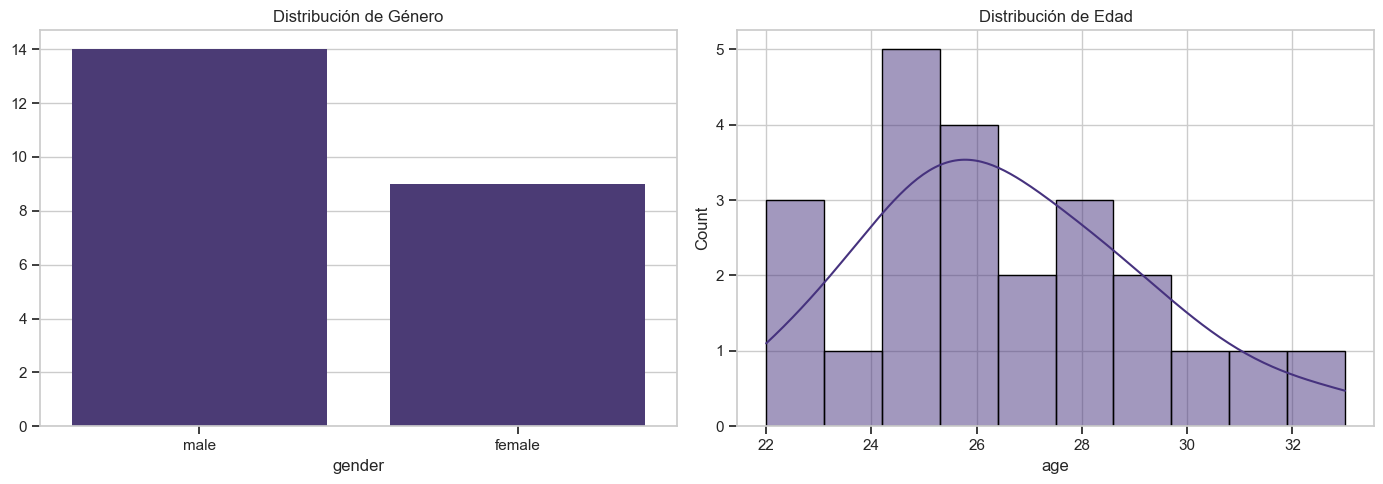

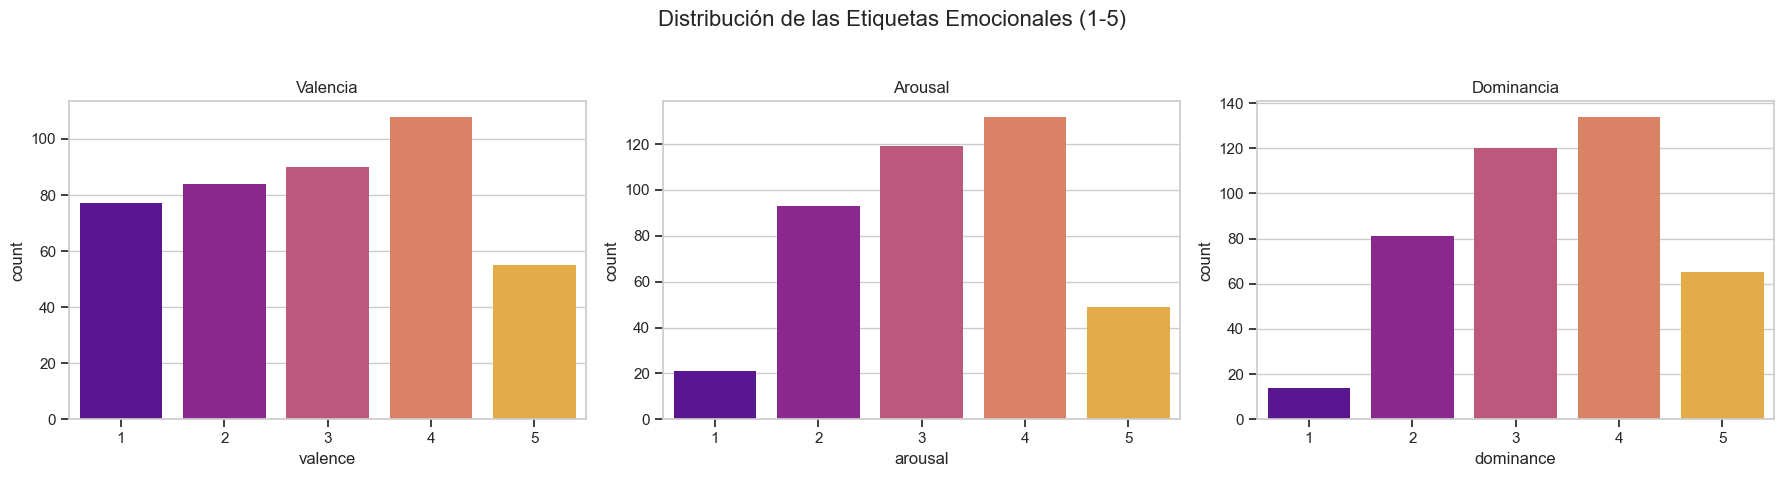

In [5]:
if 'df' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    gender_counts = df.drop_duplicates(subset='participant')['gender'].value_counts()
    sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[0])
    axes[0].set_title('Distribución de Género')
    age_dist = df.drop_duplicates(subset='participant')['age']
    sns.histplot(age_dist, bins=10, kde=True, ax=axes[1])
    axes[1].set_title('Distribución de Edad')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Distribución de las Etiquetas Emocionales (1-5)', fontsize=16)
    sns.countplot(x='valence', data=df, ax=axes[0], palette='plasma').set_title('Valencia')
    sns.countplot(x='arousal', data=df, ax=axes[1], palette='plasma').set_title('Arousal')
    sns.countplot(x='dominance', data=df, ax=axes[2], palette='plasma').set_title('Dominancia')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### 4.2. Estadísticas, Normalidad y Correlación de Etiquetas

Estadísticas Descriptivas de las Etiquetas Emocionales:


,valence,arousal,dominance
count,414.000000,414.000000,414.000000
mean,2.951691,3.229469,3.374396
std,1.319470,1.081655,1.070141
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,3.000000
50%,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000



Prueba de Normalidad de Shapiro-Wilk:
  - Valence: p-value=0.000 (No Normal)
  - Arousal: p-value=0.000 (No Normal)
  - Dominance: p-value=0.000 (No Normal)


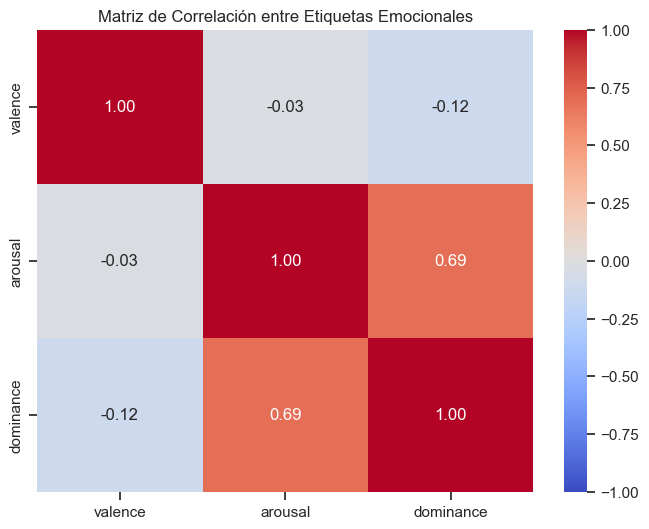

In [6]:
if 'df' in locals():
    emotion_labels = ['valence', 'arousal', 'dominance']
    print("Estadísticas Descriptivas de las Etiquetas Emocionales:")
    display(df[emotion_labels].describe())
    
    print("\nPrueba de Normalidad de Shapiro-Wilk:")
    for label in emotion_labels:
        stat, p_value = shapiro(df[label])
        normality = "Normal" if p_value > 0.05 else "No Normal"
        print(f'  - {label.capitalize()}: p-value={p_value:.3f} ({normality})')
    
    correlation_matrix = df[emotion_labels].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
    plt.title('Matriz de Correlación entre Etiquetas Emocionales')
    plt.show()

### 4.3. Variabilidad Inter-Sujeto

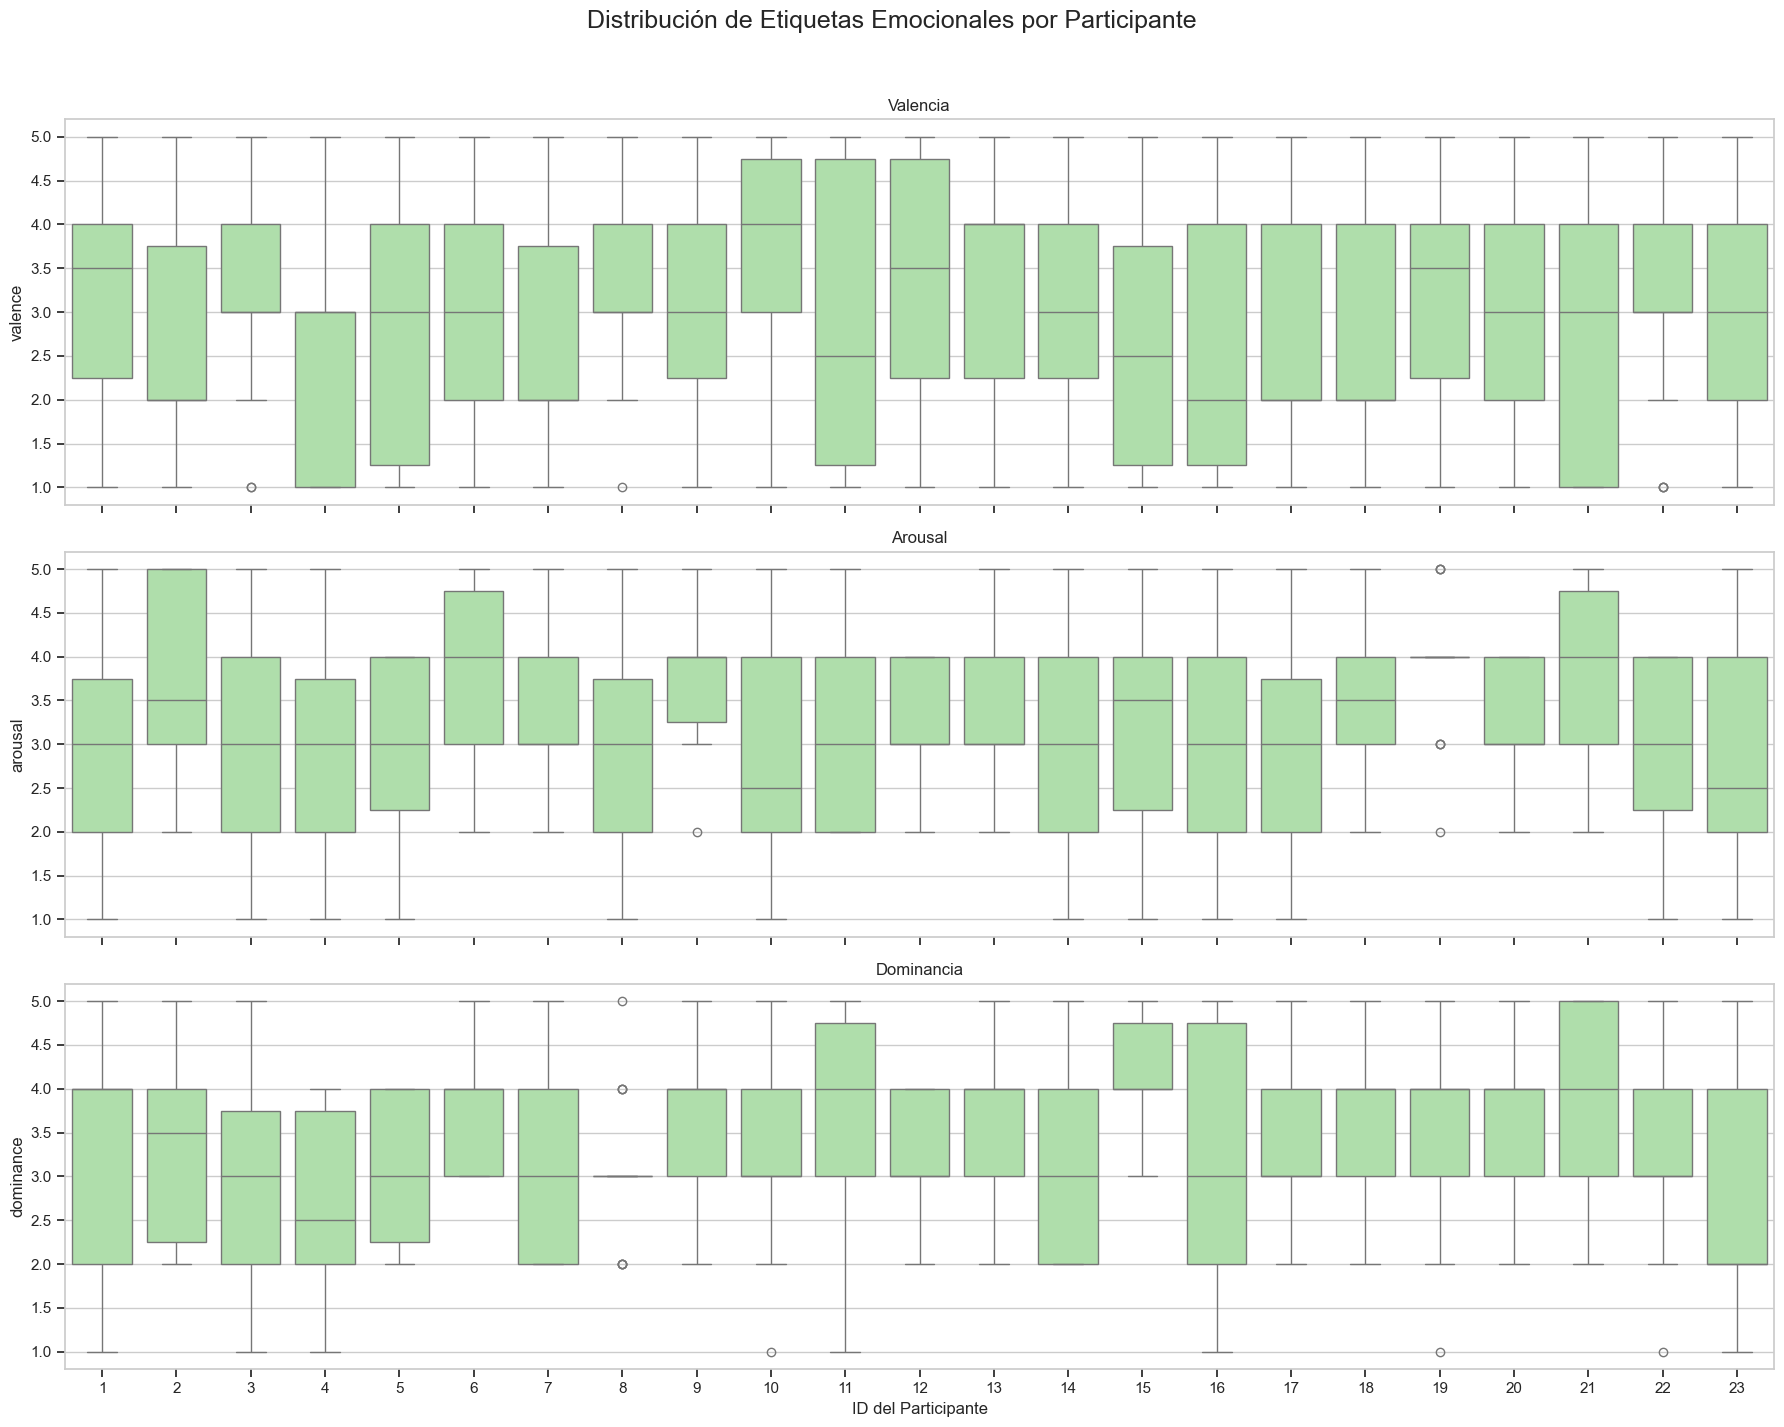

In [12]:
if 'df' in locals():
    fig, axes = plt.subplots(3, 1, figsize=(18, 15), sharex=True)
    fig.suptitle('Distribución de Etiquetas Emocionales por Participante', fontsize=18)

    # Color
    verde_claro = "#A8E6A3"

    sns.boxplot(x='participant', y='valence', data=df, ax=axes[0], color=verde_claro).set(
        xlabel=None, title='Valencia')
    sns.boxplot(x='participant', y='arousal', data=df, ax=axes[1], color=verde_claro).set(
        xlabel=None, title='Arousal')
    sns.boxplot(x='participant', y='dominance', data=df, ax=axes[2], color=verde_claro).set(
        xlabel='ID del Participante', title='Dominancia')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

## 5. Extracción de Características Fisiológicas

In [8]:
def extract_hrv_features(ecg_signal, sampling_rate):
    try:
        _, rpeaks = nk.ecg_peaks(ecg_signal, sampling_rate=sampling_rate)
        if rpeaks['ECG_R_Peaks'].size < 4: return {}
        hrv_features = nk.hrv_time(rpeaks, sampling_rate=sampling_rate, show=False)
        return hrv_features.to_dict('records')[0]
    except Exception: return {}

def extract_eeg_psd_features(eeg_signal, sampling_rate, electrode_index=0):
    bands = {'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 45)}
    eeg_channel = eeg_signal[:, electrode_index]
    freqs, psd = scipy_signal.welch(eeg_channel, fs=sampling_rate, nperseg=sampling_rate*2)
    total_power = np.trapz(psd, freqs)
    if total_power == 0: return {f'psd_{band}_rel': 0 for band in bands}
    features = {}
    for band, (low, high) in bands.items():
        idx_band = np.logical_and(freqs >= low, freqs <= high)
        band_power = np.trapz(psd[idx_band], freqs[idx_band])
        features[f'psd_{band}_rel'] = band_power / total_power
    return features

### 5.1. Creación y Limpieza del DataFrame de Características
Aplicamos las funciones de extracción a todo el dataset. Este proceso puede tardar unos minutos.

In [9]:
if 'df' in locals():
    features_list = []
    for index, row in df.iterrows():
        trial_features = {'participant': row['participant'], 'video': row['video']}
        
        hrv_baseline = extract_hrv_features(row['ecg_baseline'], fs_ecg)
        hrv_stimuli = extract_hrv_features(row['ecg_stimuli'], fs_ecg)
        psd_baseline = extract_eeg_psd_features(row['eeg_baseline'], fs_eeg)
        psd_stimuli = extract_eeg_psd_features(row['eeg_stimuli'], fs_eeg)
        
        trial_features.update({f'hrv_{k}_baseline': v for k, v in hrv_baseline.items()})
        trial_features.update({f'hrv_{k}_stimuli': v for k, v in hrv_stimuli.items()})
        trial_features.update({f'eeg_{k}_baseline': v for k, v in psd_baseline.items()})
        trial_features.update({f'eeg_{k}_stimuli': v for k, v in psd_stimuli.items()})
        trial_features.update({'valence': row['valence'], 'arousal': row['arousal'], 'dominance': row['dominance']})
        features_list.append(trial_features)
    
    # Crear el DataFrame SIN eliminar filas todavía
    features_df = pd.DataFrame(features_list)
    print(f"DataFrame de características creado con {features_df.shape[0]} filas.")

    # Inspeccionar valores nulos
    print("\nConteo de valores nulos en columnas clave:")
    key_cols_nulls = features_df[['hrv_HRV_RMSSD_stimuli', 'eeg_psd_alpha_rel_stimuli']].isnull().sum()
    print(key_cols_nulls)
    
    # Eliminar filas donde las características clave no pudieron ser calculadas
    initial_rows = len(features_df)
    features_df.dropna(subset=['hrv_HRV_RMSSD_stimuli', 'eeg_psd_alpha_rel_stimuli'], inplace=True)
    print(f"\nSe eliminaron {initial_rows - len(features_df)} filas con datos nulos.")
    print(f"El DataFrame final tiene {features_df.shape[0]} filas.")

    display(features_df.head())

DataFrame de características creado con 414 filas.

Conteo de valores nulos en columnas clave:
hrv_HRV_RMSSD_stimuli        0
eeg_psd_alpha_rel_stimuli    0
dtype: int64

Se eliminaron 0 filas con datos nulos.
El DataFrame final tiene 414 filas.


,participant,video,hrv_HRV_MeanNN_baseline,hrv_HRV_SDNN_baseline,hrv_HRV_SDANN1_baseline,hrv_HRV_SDNNI1_baseline,hrv_HRV_SDANN2_baseline,hrv_HRV_SDNNI2_baseline,hrv_HRV_SDANN5_baseline,hrv_HRV_SDNNI5_baseline,...,eeg_psd_beta_rel_baseline,eeg_psd_gamma_rel_baseline,eeg_psd_delta_rel_stimuli,eeg_psd_theta_rel_stimuli,eeg_psd_alpha_rel_stimuli,eeg_psd_beta_rel_stimuli,eeg_psd_gamma_rel_stimuli,valence,arousal,dominance
0,1,1,1485.532407,149.195541,NaN,NaN,NaN,NaN,NaN,NaN,...,0.433315,0.009615,0.135604,0.070226,0.008929,0.668855,0.014596,4,3,2
1,1,2,1388.353924,94.496616,NaN,NaN,NaN,NaN,NaN,NaN,...,0.883156,0.018075,0.070924,0.036127,0.008142,0.774828,0.017988,3,3,1
2,1,3,1608.213682,97.277153,NaN,NaN,NaN,NaN,NaN,NaN,...,0.819651,0.019789,0.056261,0.037750,0.010264,0.839018,0.018139,5,4,4
3,1,4,1535.403481,79.306327,NaN,NaN,NaN,NaN,NaN,NaN,...,0.925536,0.019111,0.017758,0.030868,0.008476,0.916631,0.022145,4,3,2
4,1,5,1558.593750,166.982508,NaN,NaN,NaN,NaN,NaN,NaN,...,0.907314,0.022672,0.014415,0.036151,0.007570,0.915682,0.017568,4,4,4


## 6. Búsqueda de Features Relevantes

### 6.1. Correlación entre Características Fisiológicas y Emociones
Ahora que tenemos un DataFrame limpio, investigamos qué métricas fisiológicas se correlacionan con las dimensiones emocionales.

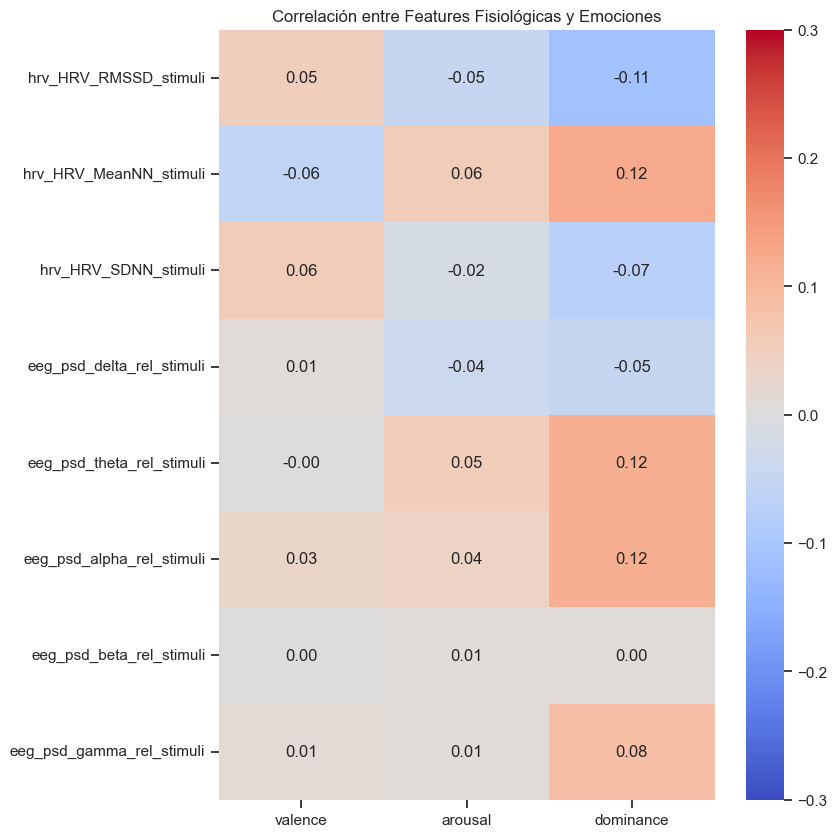

In [10]:
if 'features_df' in locals() and not features_df.empty:
    # Seleccionar un subconjunto de características para mayor claridad
    hrv_cols = ['hrv_HRV_RMSSD_stimuli', 'hrv_HRV_MeanNN_stimuli', 'hrv_HRV_SDNN_stimuli']
    eeg_cols = [col for col in features_df.columns if 'eeg' in col and 'stimuli' in col]
    emotion_cols = ['valence', 'arousal', 'dominance']
    
    cols_to_correlate = hrv_cols + eeg_cols + emotion_cols
    correlation_matrix_full = features_df[cols_to_correlate].corr()
    emotion_correlations = correlation_matrix_full[emotion_cols].drop(emotion_cols)
    
    plt.figure(figsize=(8, 10))
    sns.heatmap(emotion_correlations, annot=True, cmap='coolwarm', fmt='.2f', vmin=-0.3, vmax=0.3)
    plt.title('Correlación entre Features Fisiológicas y Emociones')
    plt.show()

### 6.2. Comparación Estadística (Baseline vs. Estímulo)

In [11]:
if 'features_df' in locals() and not features_df.empty:
    features_to_test = {
        'HRV (RMSSD)': ('hrv_HRV_RMSSD_baseline', 'hrv_HRV_RMSSD_stimuli'),
        'Potencia Relativa Alfa': ('eeg_psd_alpha_rel_baseline', 'eeg_psd_alpha_rel_stimuli'),
        'Potencia Relativa Beta': ('eeg_psd_beta_rel_baseline', 'eeg_psd_beta_rel_stimuli')
    }
    
    results = []
    for name, (baseline_col, stimuli_col) in features_to_test.items():
        t_stat, p_value = ttest_rel(features_df[baseline_col], features_df[stimuli_col])
        results.append({'Característica': name, 'P-value': p_value})
    
    results_df = pd.DataFrame(results)
    print("Resultados de la Prueba T Pareada (Baseline vs. Stimuli)")
    display(results_df)

Resultados de la Prueba T Pareada (Baseline vs. Stimuli)


,Característica,P-value
0,HRV (RMSSD),0.014170
1,Potencia Relativa Alfa,0.650807
2,Potencia Relativa Beta,0.207120


## 7. Conclusiones del EDA y Próximos Pasos

Este análisis exploratorio avanzado del dataset DREAMER revela varios puntos clave:

1.  **Calidad de Datos y Retos**: El dataset contiene datos fisiológicos de alta calidad, aunque no todos los segmentos de señal permiten una extracción de características robusta (ej. HRV), lo que requiere una limpieza de datos cuidadosa. La alta variabilidad en las respuestas entre sujetos es el principal reto a abordar.

2.  **Respuesta Fisiológica Medible**: Se demostró una diferencia estadísticamente significativa (p < 0.05) en las métricas de HRV y EEG entre las fases de línea base y estímulo. Esto valida que los videos indujeron cambios fisiológicos detectables y que estas métricas son informativas.

3.  **Correlaciones Clave Fisiología-Emoción**: El análisis de correlación identificó un conjunto de `features` prometedoras. 
    - El **Arousal** se asocia negativamente con la potencia Alfa y positivamente con la potencia Beta, consistente con estados de mayor alerta. También se correlaciona con una menor variabilidad cardíaca (RMSSD) y menor intervalo entre latidos (mayor ritmo cardíaco).
    - La **Valencia** muestra una tendencia opuesta, aunque con correlaciones más débiles, asociándose con mayor potencia Alfa (relajación).

### Propuestas de Características para Machine Learning

Basado en este EDA, un conjunto inicial de `features` para un modelo de clasificación de emociones debería incluir:

*   **Para predecir Arousal**: 
    - **ECG**: `HRV_RMSSD`, `HRV_MeanNN`, `HRV_SDNN`.
    - **EEG**: `psd_alpha_rel`, `psd_beta_rel`.

*   **Para predecir Valencia**:
    - Las mismas características que para Arousal. Podría ser útil explorar la asimetría entre hemisferios en la banda Alfa, una característica comúnmente asociada a la valencia, lo que requeriría procesar más canales de EEG.

### Próximos Pasos

El siguiente paso lógico es el preprocesamiento de las señales (filtrado adicional, eliminación de artefactos) y la construcción de modelos de machine learning (como SVM, Random Forest) o deep learning (CNNs, LSTMs) utilizando las características identificadas. La **variabilidad inter-sujeto** deberá ser abordada durante el modelado, ya sea mediante la normalización de características por sujeto (z-score) o entrenando modelos personalizados.

In [13]:
!jupyter nbconvert --to webpdf EDA_DREAMER.ipynb

[NbConvertApp] Converting notebook EDA_DREAMER.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 478718 bytes to EDA_DREAMER.pdf
